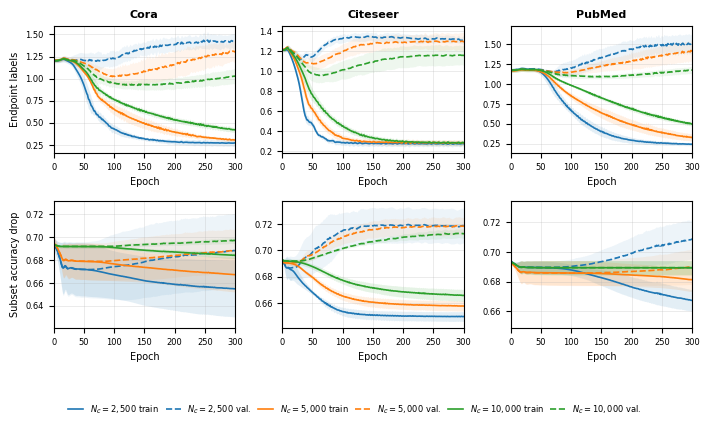

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Input CSVs
# ---------------------------------------------------------------------

CSV_FILES = {
    "Cora": Path(
        r"rq3_selector_training_stats_cora_ml_candidates2500-5000-10000_seeds0-1-2-3-4 (3).csv"
    ),
    "Citeseer": Path(
        r"rq3_selector_training_stats_citeseer_candidates2500-5000-10000_seeds0-1-2-3-4 (1).csv"
    ),
    "PubMed": Path(
        r"rq3_selector_training_stats_pubmed_candidates2500-5000-10000_seeds0-1-2-3-4 (1).csv"
    ),
}

CANDIDATE_SIZES = [2500, 5000, 10000]

SCORING_MODES = {
    "endpoint": "Endpoint labels",
    "subset_accuracy_drop": "Subset accuracy drop",
}


# ---------------------------------------------------------------------
# Figure setup
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(7.2, 4.2),
)

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

size_to_color = {
    size: default_colors[i]
    for i, size in enumerate(CANDIDATE_SIZES)
}


# ---------------------------------------------------------------------
# Plot each dataset
# ---------------------------------------------------------------------

for col_idx, (dataset_name, csv_path) in enumerate(CSV_FILES.items()):

    df = pd.read_csv(csv_path)

    for row_idx, (scoring_mode, row_label) in enumerate(SCORING_MODES.items()):

        ax = axes[row_idx, col_idx]

        mode_df = df[
            df["scoring_mode"] == scoring_mode
        ].copy()

        for candidate_size in CANDIDATE_SIZES:

            plot_df = (
                mode_df[
                    mode_df["candidate_set_size"] == candidate_size
                ]
                .sort_values("epoch")
            )

            if plot_df.empty:
                continue

            color = size_to_color[candidate_size]

            epoch = plot_df["epoch"].to_numpy()

            # ---------------------------------------------------------
            # Training loss
            # ---------------------------------------------------------

            train_mean = plot_df["train_loss_mean"].to_numpy()
            train_std = plot_df["train_loss_std"].to_numpy()

            ax.plot(
                epoch,
                train_mean,
                color=color,
                linestyle="-",
                linewidth=1.2,
            )

            ax.fill_between(
                epoch,
                train_mean - train_std,
                train_mean + train_std,
                color=color,
                alpha=0.12,
                linewidth=0,
            )

            # ---------------------------------------------------------
            # Validation loss
            # ---------------------------------------------------------

            val_mean = plot_df["validation_loss_mean"].to_numpy()
            val_std = plot_df["validation_loss_std"].to_numpy()

            ax.plot(
                epoch,
                val_mean,
                color=color,
                linestyle="--",
                linewidth=1.2,
            )

            ax.fill_between(
                epoch,
                val_mean - val_std,
                val_mean + val_std,
                color=color,
                alpha=0.08,
                linewidth=0,
            )

        # -------------------------------------------------------------
        # Axis formatting
        # -------------------------------------------------------------

        ax.grid(
            True,
            linewidth=0.5,
            alpha=0.35,
        )

        ax.tick_params(
            axis="both",
            labelsize=6,
        )

        ax.set_xlim(0, 300)

        ax.set_xlabel(
            "Epoch",
            fontsize=7,
        )

        if col_idx == 0:
            ax.set_ylabel(
                row_label,
                fontsize=7,
            )

        if row_idx == 0:
            ax.set_title(
                dataset_name,
                fontsize=8,
                fontweight="bold",
            )


# ---------------------------------------------------------------------
# Shared legend
# ---------------------------------------------------------------------

legend_handles = []

for candidate_size in CANDIDATE_SIZES:

    color = size_to_color[candidate_size]

    train_handle, = axes[0, 0].plot(
        [],
        [],
        color=color,
        linestyle="-",
        linewidth=1.2,
        label=rf"$N_{{\mathcal{{C}}}}={candidate_size:,}$ train",
    )

    val_handle, = axes[0, 0].plot(
        [],
        [],
        color=color,
        linestyle="--",
        linewidth=1.2,
        label=rf"$N_{{\mathcal{{C}}}}={candidate_size:,}$ val.",
    )

    legend_handles.extend(
        [train_handle, val_handle]
    )


fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=6,
    frameon=False,
    fontsize=6,
    handlelength=1.8,
    columnspacing=0.8,
)


# ---------------------------------------------------------------------
# Layout and export
# ---------------------------------------------------------------------

fig.tight_layout(
    rect=[0, 0.09, 1, 1],
    h_pad=1.0,
    w_pad=0.8,
)

plt.savefig(
    "selector_training_dynamics_new.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()